# Analisis descriptivo del panel de estudiantes

**Hipotesis descriptiva:** una mayor distancia entre el domicilio del estudiante y la institucion de educacion superior, o una menor accesibilidad al transporte publico, podria estar asociada con un menor desempeno academico.

Este notebook no estima efectos causales ni modelos econometricos. Su objetivo es producir evidencia descriptiva limpia, reproducible y util para orientar el analisis posterior.

## 0. Configuracion

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from IPython.display import Markdown, display

from eda_utils import (
    configurar_estilo,
    crear_directorios,
    cargar_panel,
    preparar_panel,
    filtrar_convocatoria,
    resumen_general,
    estudiantes_por_periodo,
    estadisticos_descriptivos,
    ultima_observacion_por_estudiante,
    matriz_correlacion,
    interpretar_correlaciones,
    resumen_quintiles,
    tasa_abandono_acumulada_por_quintil,
    plot_distribuciones,
    plot_comparacion_estado,
    plot_histograma_por_estado,
    plot_curvas_promedio,
    plot_matriz_correlacion,
    plot_relacion_bivariada,
    plot_quintiles,
    plot_tasa_abandono_acumulada,
    generar_conclusiones,
    guardar_texto,
    exportar_tablas_convocatoria,
)

configurar_estilo()

DATA_PATH = Path("panel_insumo_refactorizado.xlsx")
FIGURES_DIR, OUTPUTS_DIR = crear_directorios("../figures", "../outputs")

## 1. Carga y filtros del estudio

Se conserva unicamente: `NIVEL_FORMACION == UNIVERSITARIO`, `TIPO_MODALIDAD == PRESENCIAL`, `periodo_orden <= 8`, estados `Matriculado` y `Abandono`, y convocatorias `JU3` y `JU4`.

In [2]:
panel_raw = cargar_panel(DATA_PATH)
panel = preparar_panel(panel_raw)

panel.shape

(27484, 46)

In [3]:
panel[[
    "CONVOCATORIA",
    "ID_PERSONA",
    "periodo_orden",
    "estado",
    "distancia_ies",
    "sitp_cercanos",
    "tm_cercanos",
    "acceso_transporte",
    "pct_aprob_acum",
]].head()

,CONVOCATORIA,ID_PERSONA,periodo_orden,estado,distancia_ies,sitp_cercanos,tm_cercanos,acceso_transporte,pct_aprob_acum
7,JU4,62002.0,1,Matriculado,7390.042348,37,0,37,0.032308
8,JU4,62002.0,2,Matriculado,7390.042348,37,0,37,0.144936
9,JU4,62002.0,3,Matriculado,7390.042348,37,0,37,0.224359
19,JU3,247289.0,1,Matriculado,2556.552204,38,0,38,0.042162
20,JU3,247289.0,2,Matriculado,2556.552204,38,0,38,0.188108


# Convocatoria JU3

In [4]:
ju3 = filtrar_convocatoria(panel, "JU3")
exportar_tablas_convocatoria(ju3, "JU3", OUTPUTS_DIR)

resumen_general(ju3)

,indicador,valor
0,Observaciones panel-periodo,13278
1,Estudiantes unicos,2079
2,Periodos observados,7
3,Matriculados (ultimo periodo disponible),1846
4,Abandonos (ultimo periodo disponible),233


## JU3 - Estudiantes por periodo

In [5]:
estudiantes_por_periodo(ju3)

,periodo_orden,Abandono,Matriculado,total
0,1,14,1818,1832
1,2,44,1899,1943
2,3,79,1837,1916
3,4,118,1792,1910
4,5,166,1742,1908
5,6,201,1685,1886
6,7,233,1650,1883


## JU3 - Estadisticos descriptivos

In [6]:
estadisticos_descriptivos(ju3)

,n,media,mediana,desv_est,min,1%,5%,10%,25%,75%,90%,95%,99%,max
distancia_ies,13278.0,10981.048,10855.283,5276.701,205.617,1263.824,2877.648,4289.000,7275.533,13830.822,17152.751,21442.421,26683.623,32804.654
sitp_cercanos,13278.0,47.732,48.000,15.641,5.000,10.000,23.000,28.000,37.000,58.000,68.000,74.000,85.000,94.000
tm_cercanos,13278.0,0.644,0.000,1.152,0.000,0.000,0.000,0.000,0.000,1.000,2.000,3.000,5.000,8.000
acceso_transporte,13278.0,48.376,49.000,15.623,5.000,10.000,23.000,29.000,38.000,58.000,69.000,75.000,85.230,94.000
pct_aprob_acum,13278.0,0.284,0.275,0.191,0.000,0.000,0.024,0.037,0.126,0.425,0.542,0.605,0.762,1.000


## JU3 - Distribuciones

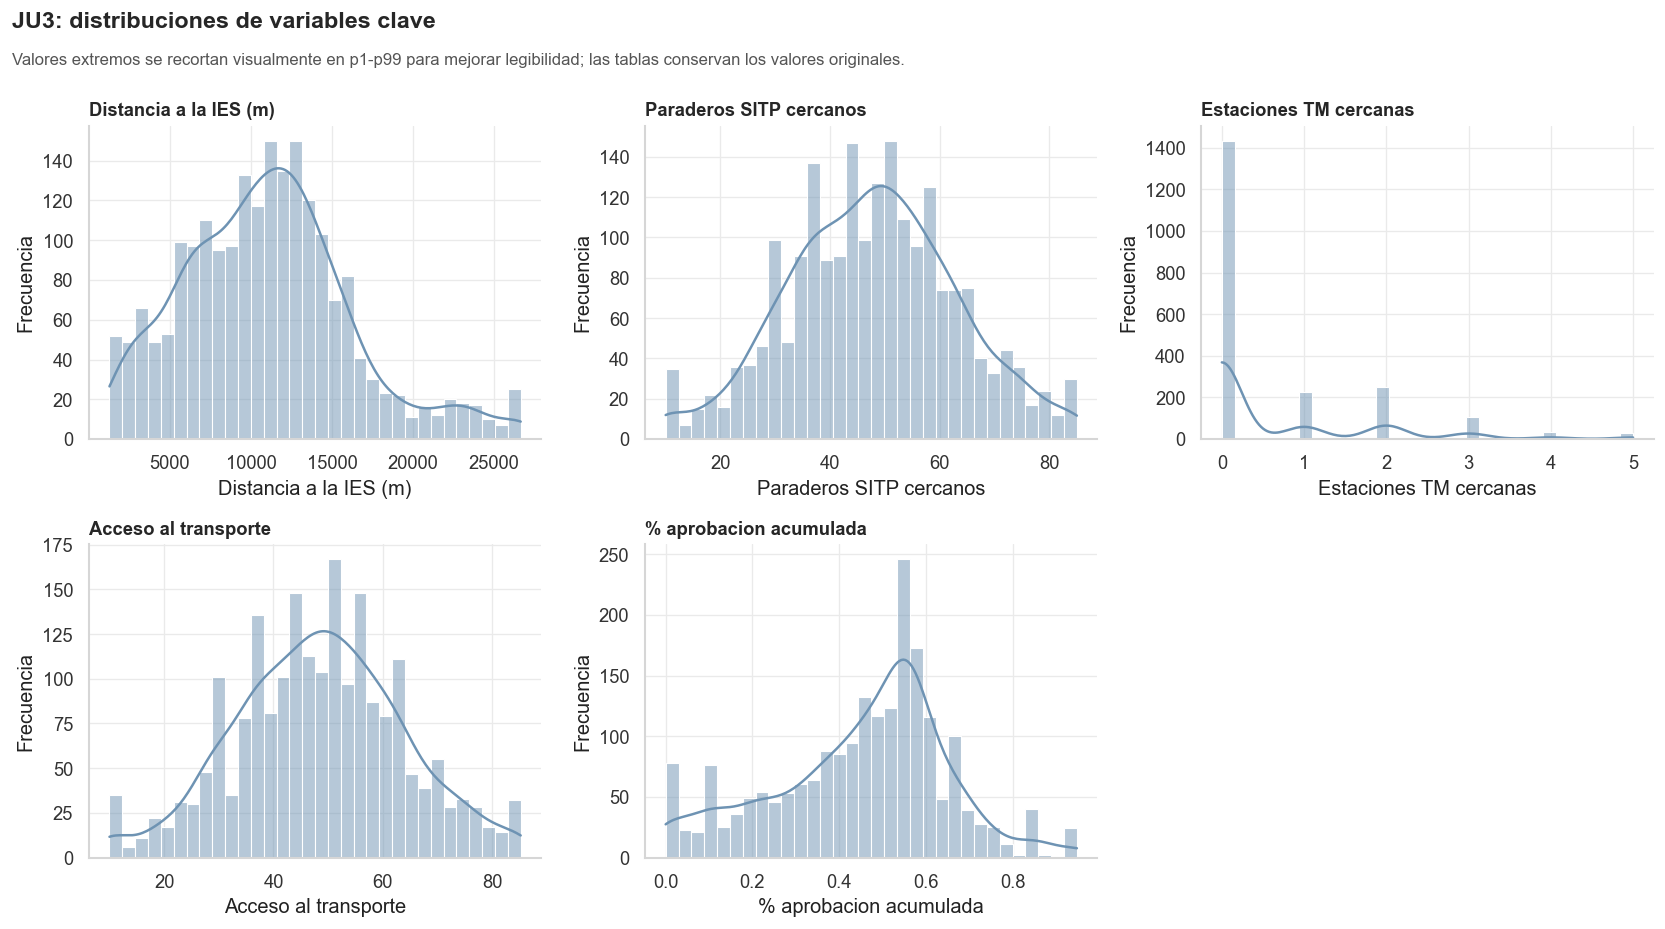

In [7]:
plot_distribuciones(ju3, "JU3", FIGURES_DIR);

## JU3 - Distancia a la IES vs desempeno

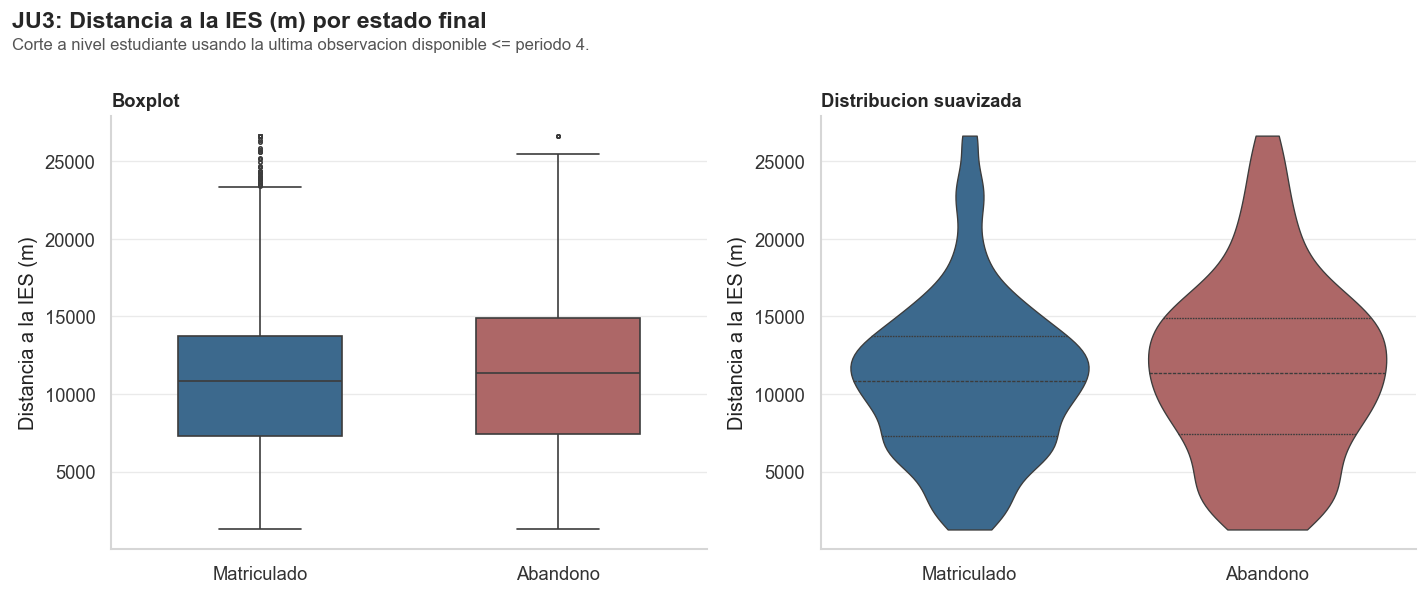

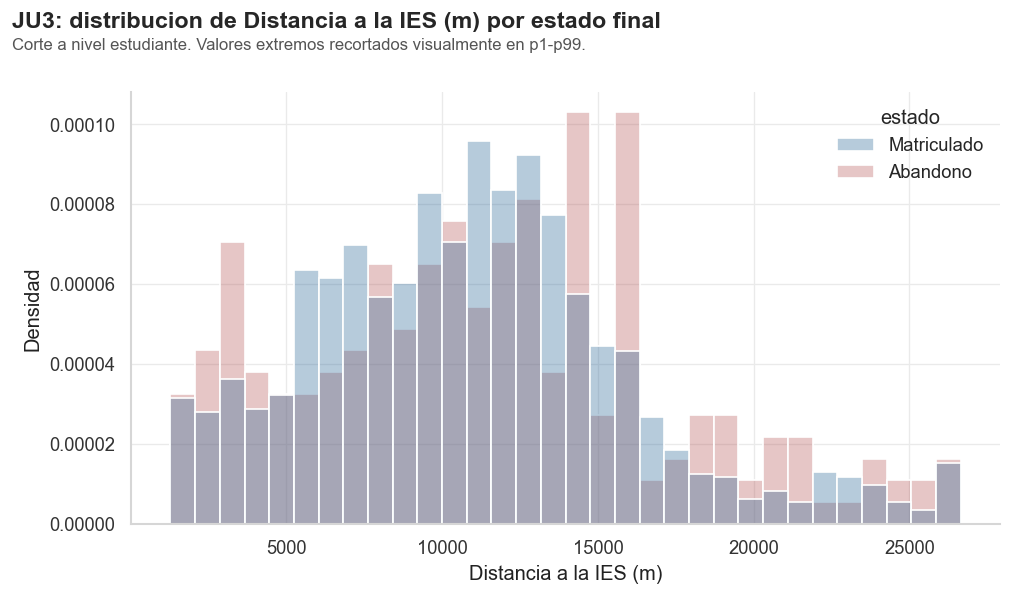

In [8]:
plot_comparacion_estado(ju3, "JU3", "distancia_ies", FIGURES_DIR);
plot_histograma_por_estado(ju3, "JU3", "distancia_ies", FIGURES_DIR);

## JU3 - Acceso al transporte vs desempeno

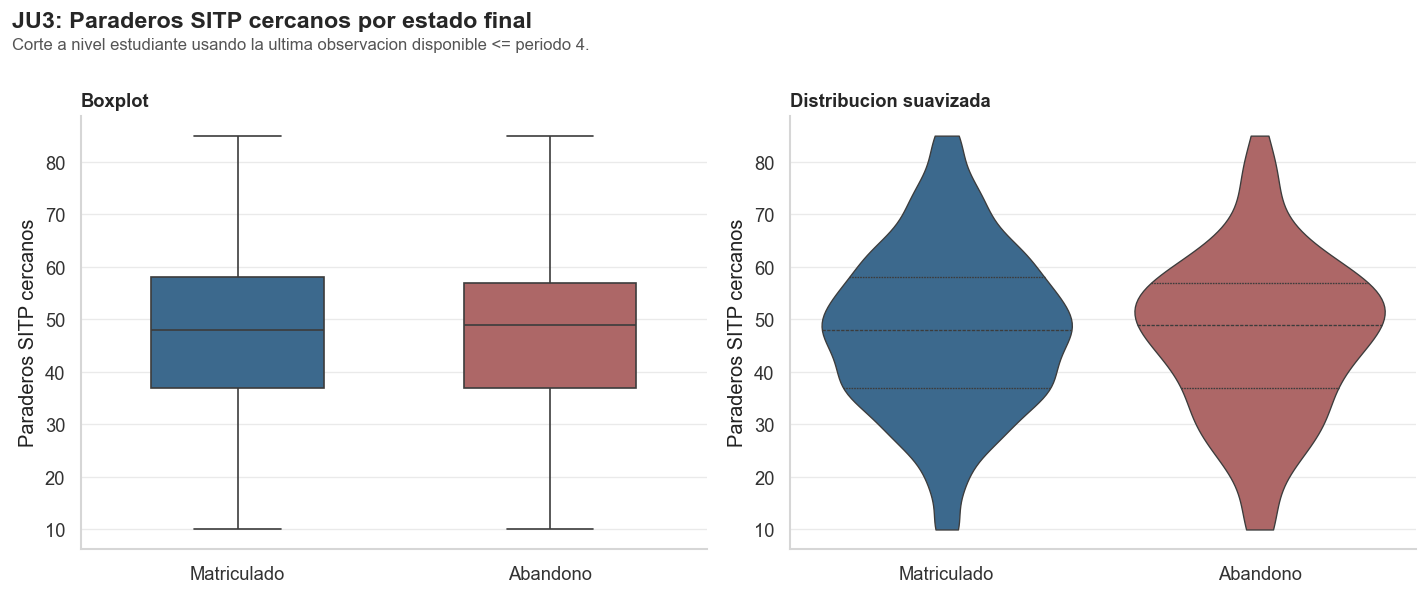

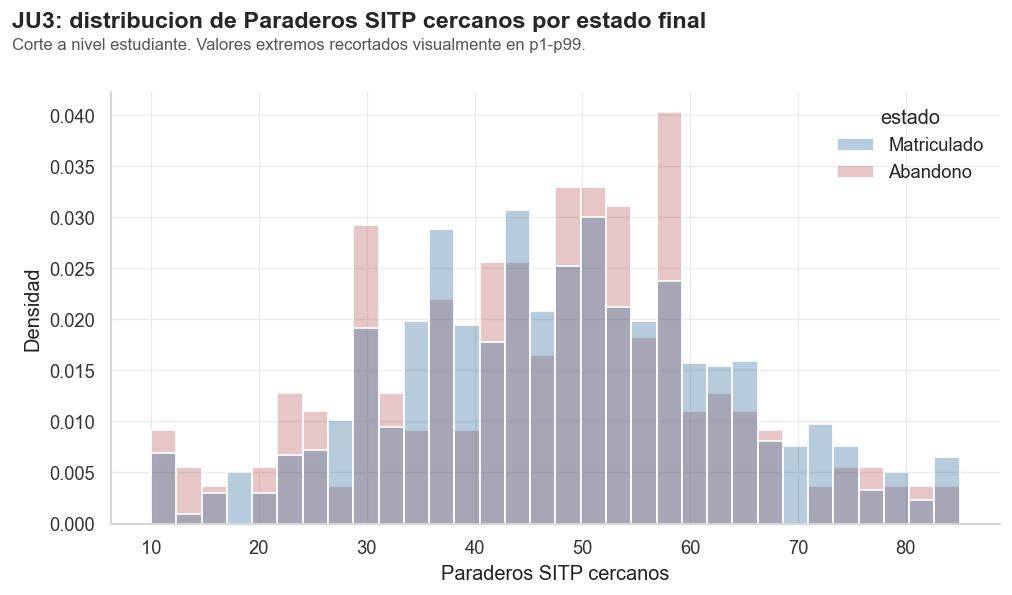

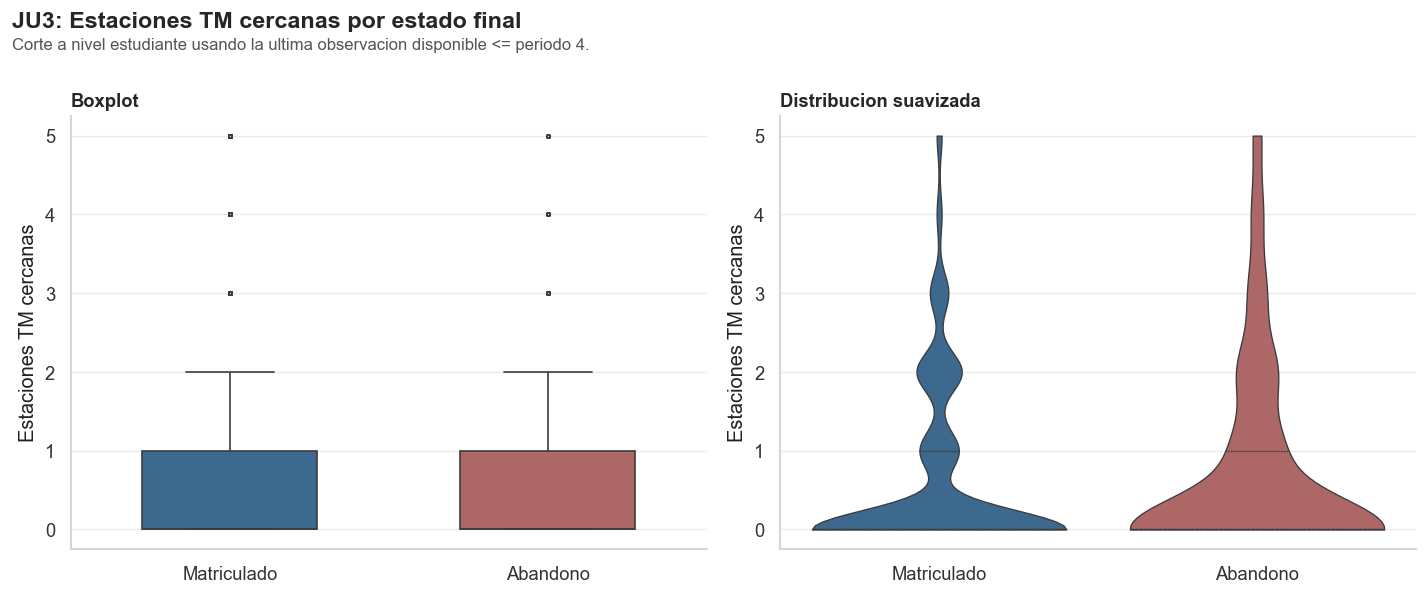

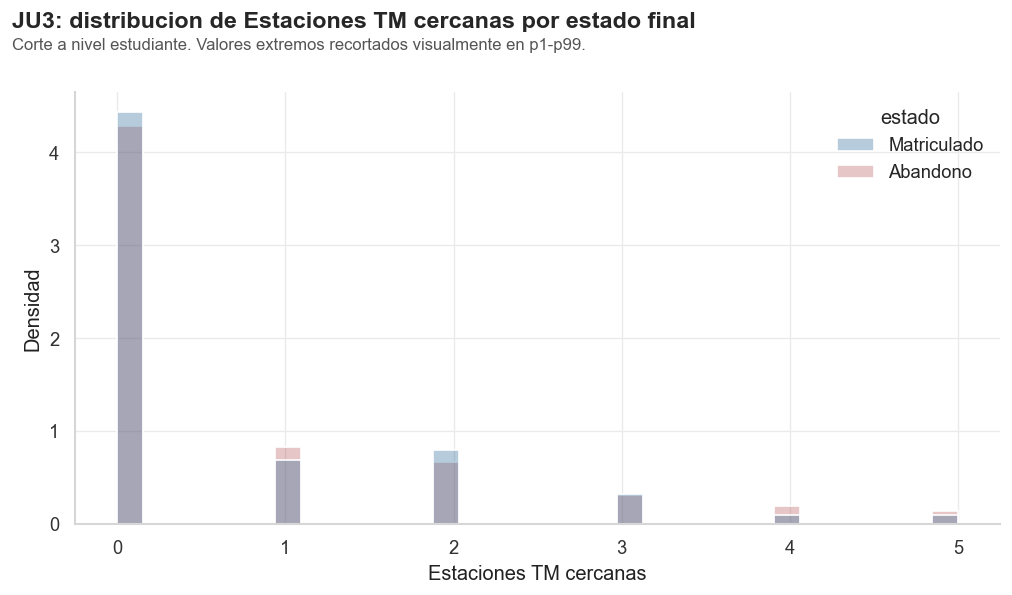

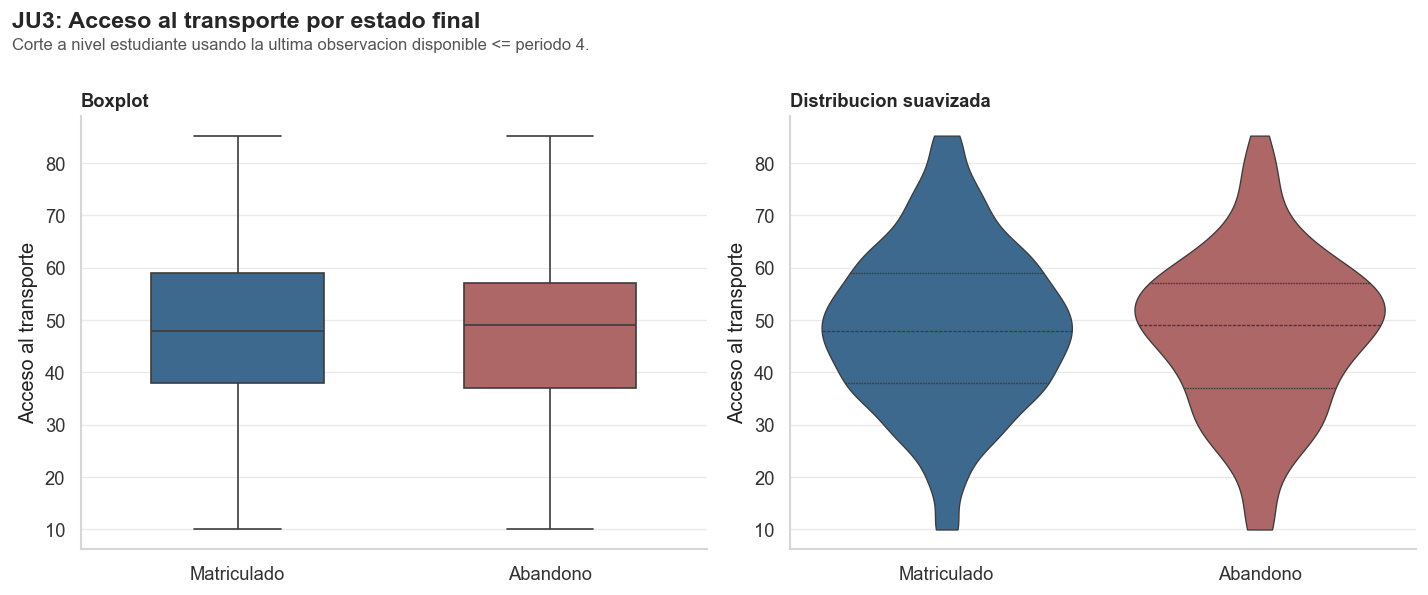

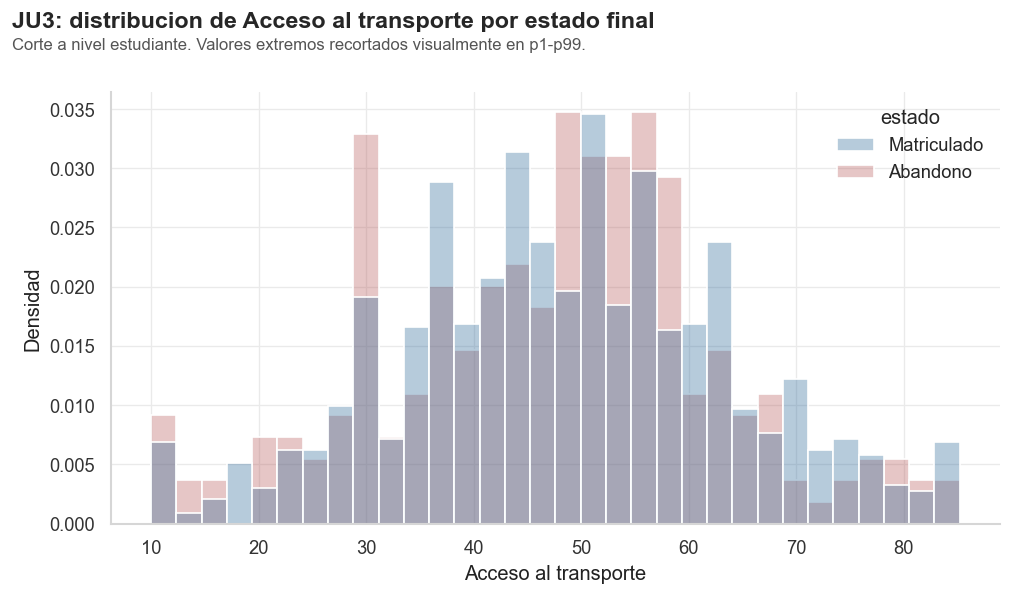

In [9]:
for variable in ["sitp_cercanos", "tm_cercanos", "acceso_transporte"]:
    plot_comparacion_estado(ju3, "JU3", variable, FIGURES_DIR)
    plot_histograma_por_estado(ju3, "JU3", variable, FIGURES_DIR)

## JU3 - Curvas promedio de desempeno

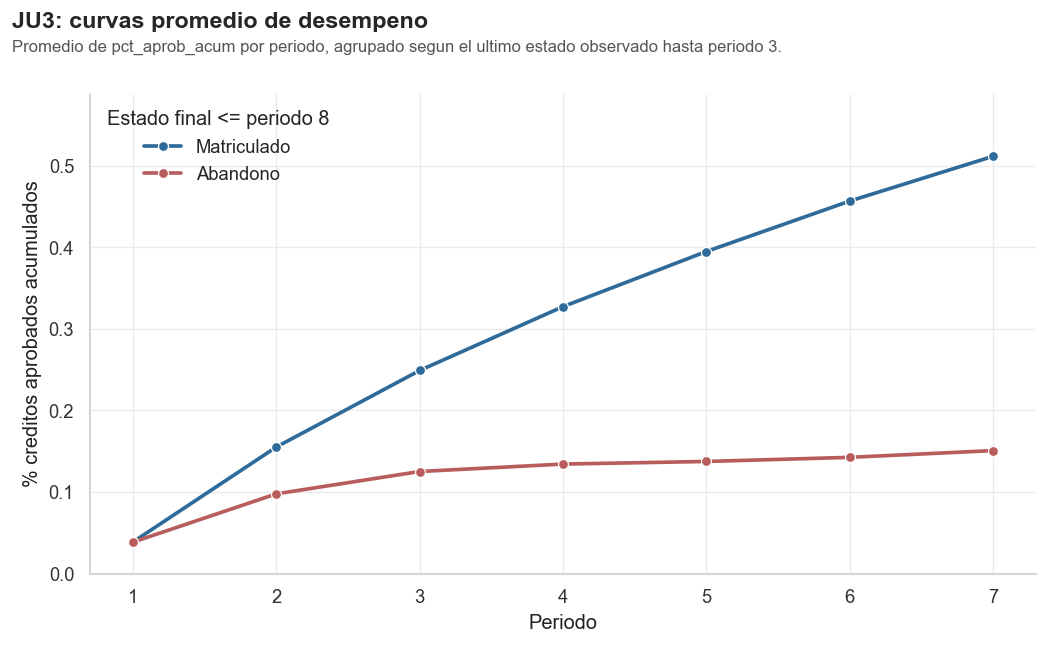

In [10]:
plot_curvas_promedio(ju3, "JU3", FIGURES_DIR);

## JU3 - Correlaciones

,distancia_ies,sitp_cercanos,tm_cercanos,acceso_transporte,pct_aprob_acum
distancia_ies,1.000,-0.040,-0.298,-0.061,-0.106
sitp_cercanos,-0.040,1.000,-0.044,0.997,0.020
tm_cercanos,-0.298,-0.044,1.000,0.029,0.039
acceso_transporte,-0.061,0.997,0.029,1.000,0.023
pct_aprob_acum,-0.106,0.020,0.039,0.023,1.000


- Distancia a la IES (m) y % aprobacion acumulada muestran una asociacion negativa de magnitud baja (r = -0.106).
- Paraderos SITP cercanos y % aprobacion acumulada muestran una asociacion positiva de magnitud baja (r = 0.020).
- Estaciones TM cercanas y % aprobacion acumulada muestran una asociacion positiva de magnitud baja (r = 0.039).
- Acceso al transporte y % aprobacion acumulada muestran una asociacion positiva de magnitud baja (r = 0.023).

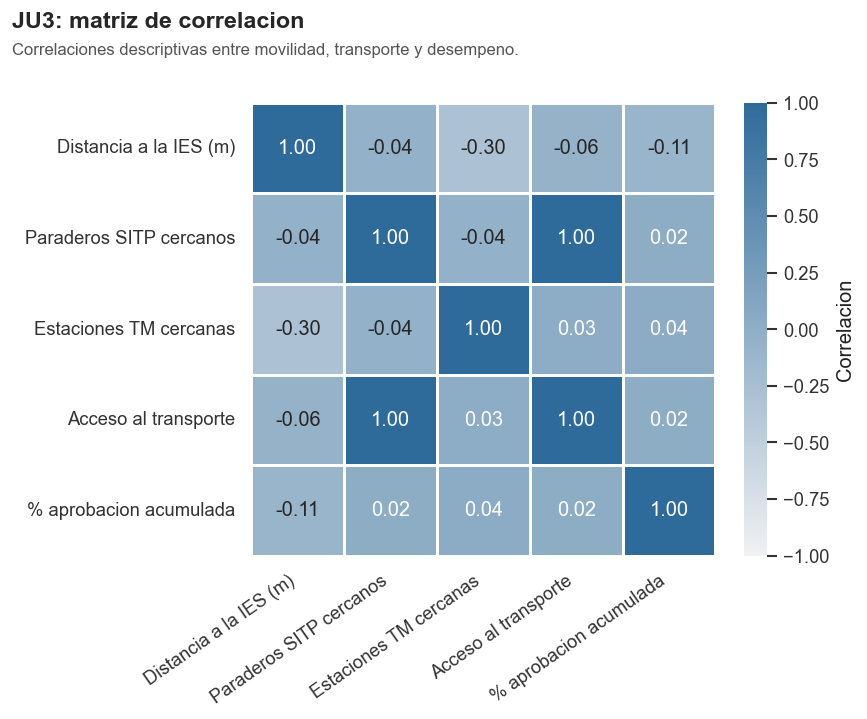

In [11]:
ju3_ultimo = ultima_observacion_por_estudiante(ju3)
corr_ju3 = matriz_correlacion(ju3_ultimo)
display(corr_ju3)
display(Markdown(interpretar_correlaciones(corr_ju3)))
plot_matriz_correlacion(ju3_ultimo, "JU3", FIGURES_DIR);

## JU3 - Relaciones bivariadas

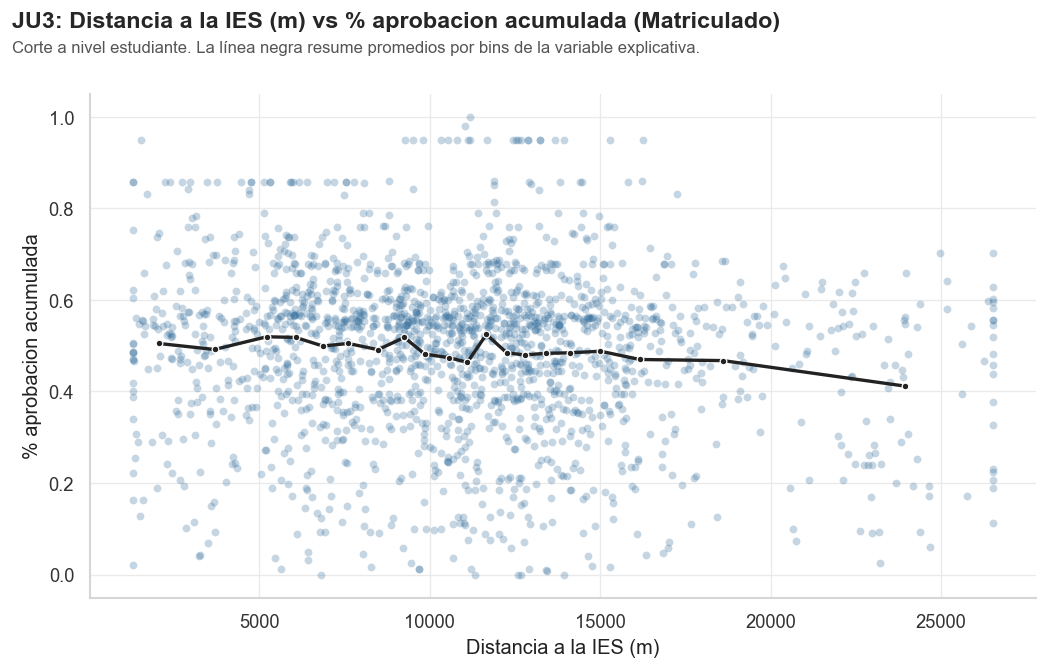

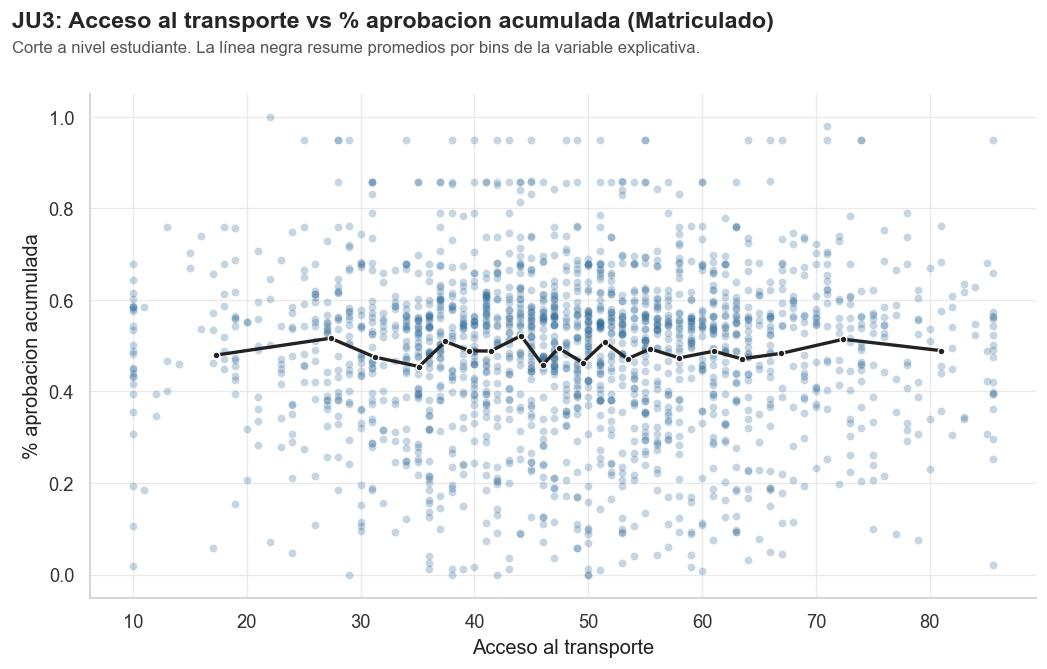

In [12]:
plot_relacion_bivariada(ju3, "JU3", "distancia_ies", "pct_aprob_acum", FIGURES_DIR);
plot_relacion_bivariada(ju3, "JU3", "acceso_transporte", "pct_aprob_acum", FIGURES_DIR);

## JU3 - Analisis por quintiles

,quintil,estudiantes,valor_min,valor_max,pct_aprob_promedio,tasa_abandono
0,Q1,416,205.6170,6406.9343,0.4708,0.1202
1,Q2,416,6414.6732,9595.1985,0.4707,0.0889
2,Q3,415,9597.4398,12022.9768,0.4526,0.0916
3,Q4,416,12054.6029,14676.5353,0.4480,0.1082
4,Q5,416,14678.7835,32804.6538,0.4094,0.1514


,quintil,estudiantes,valor_min,valor_max,pct_aprob_promedio,tasa_abandono
0,Q1,465,5,36,0.4389,0.1183
1,Q2,415,37,45,0.4709,0.0964
2,Q3,384,46,52,0.4437,0.1198
3,Q4,411,53,61,0.4346,0.1411
4,Q5,404,62,94,0.4646,0.0842


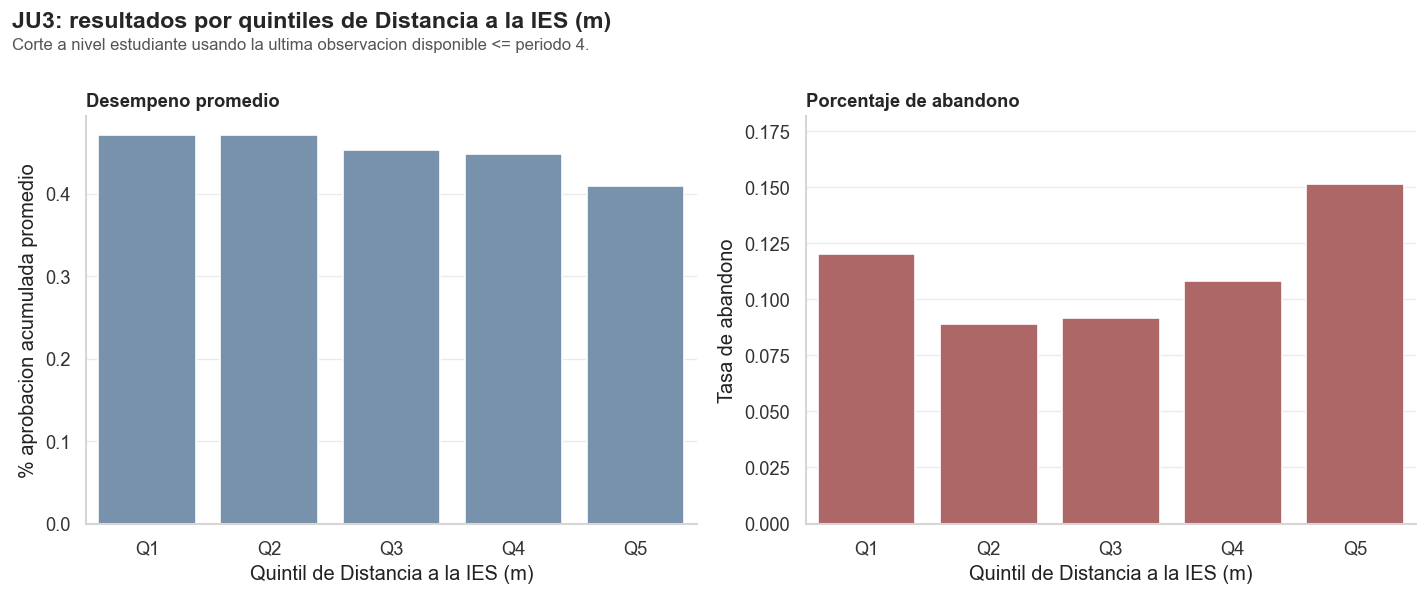

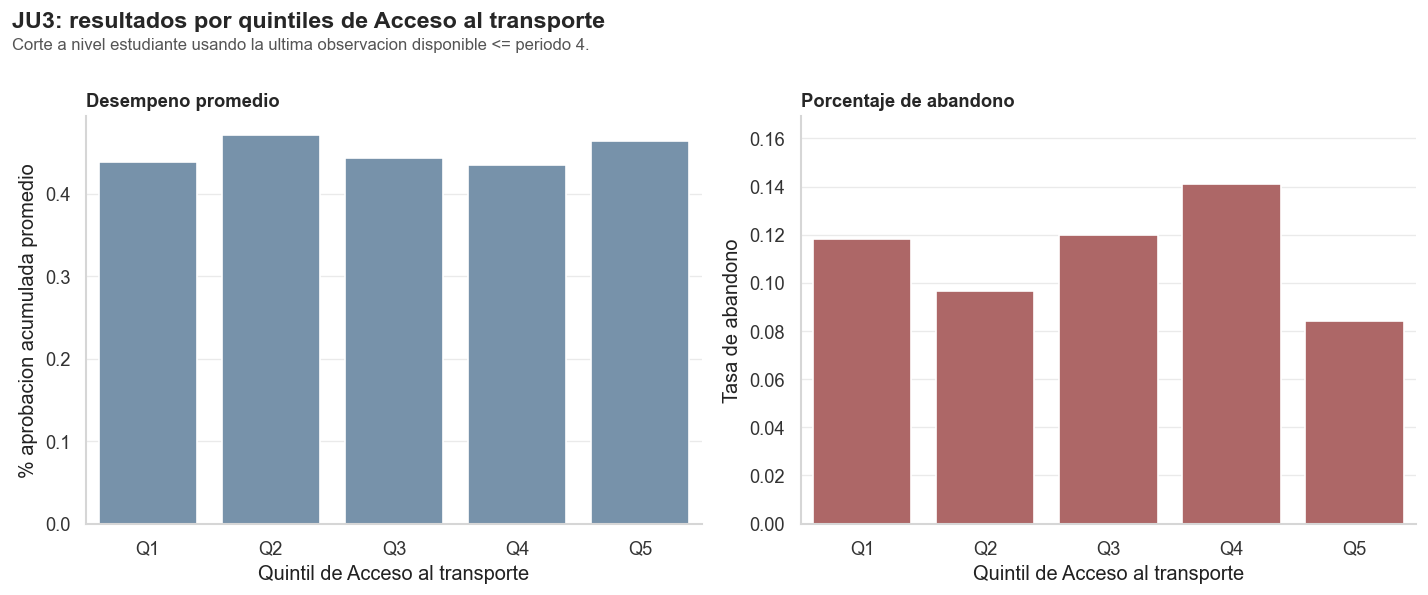

In [13]:
ju3_quintiles_distancia = resumen_quintiles(ju3, "distancia_ies")
ju3_quintiles_transporte = resumen_quintiles(ju3, "acceso_transporte")

display(ju3_quintiles_distancia)
plot_quintiles(ju3_quintiles_distancia, "JU3", "distancia_ies", FIGURES_DIR);

display(ju3_quintiles_transporte)
plot_quintiles(ju3_quintiles_transporte, "JU3", "acceso_transporte", FIGURES_DIR);

## JU3 - Tasas de abandono acumuladas

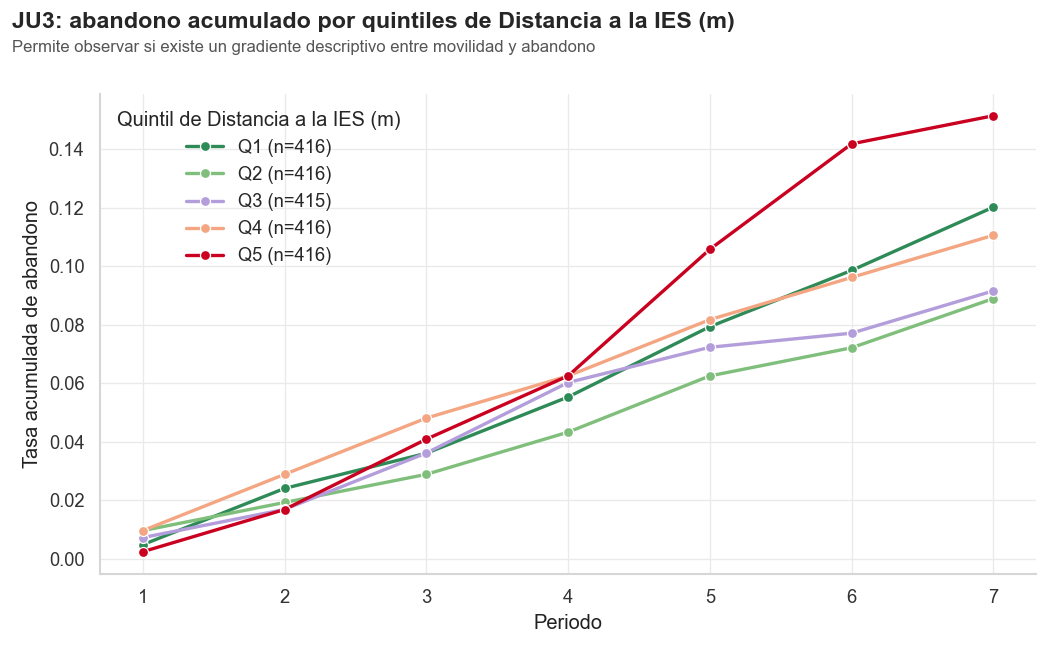

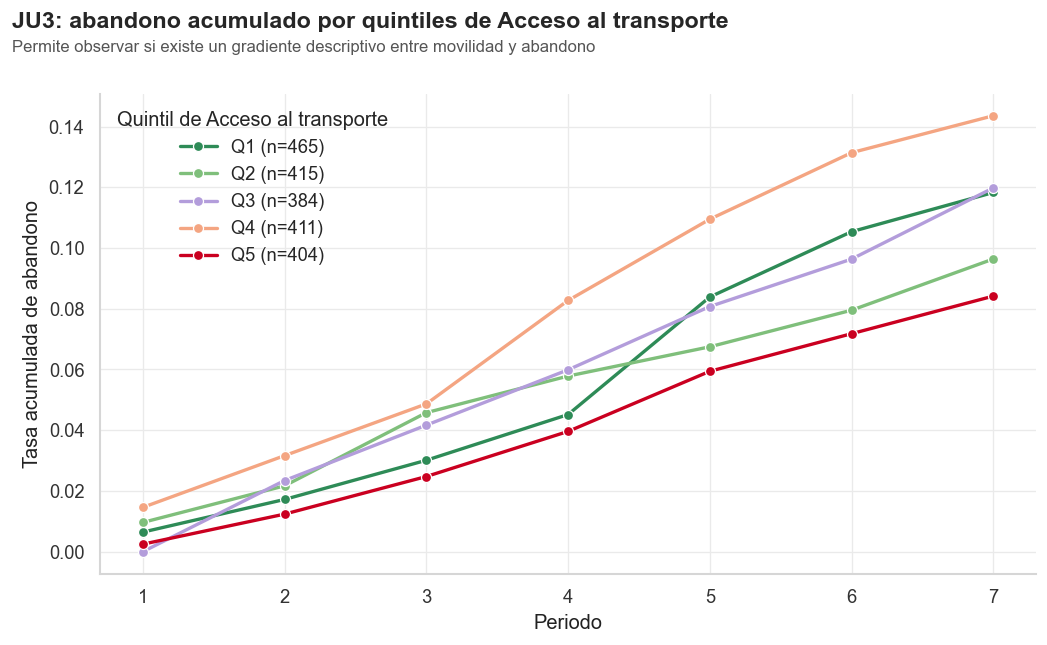

In [14]:
ju3_abandono_distancia = tasa_abandono_acumulada_por_quintil(ju3, "distancia_ies")
ju3_abandono_transporte = tasa_abandono_acumulada_por_quintil(ju3, "acceso_transporte")

plot_tasa_abandono_acumulada(ju3_abandono_distancia, "JU3", "distancia_ies", FIGURES_DIR);
plot_tasa_abandono_acumulada(ju3_abandono_transporte, "JU3", "acceso_transporte", FIGURES_DIR);

## JU3 - Conclusiones

In [15]:
conclusiones_ju3 = generar_conclusiones(ju3, "JU3")
guardar_texto(conclusiones_ju3, OUTPUTS_DIR / "ju3_conclusiones.md")
display(Markdown(conclusiones_ju3))

### Conclusiones descriptivas - JU3

- La muestra filtrada contiene **2,079 estudiantes** con ultima observacion disponible hasta el periodo 4.
- En el corte final, la distancia promedio a la IES es de **10,950 m** para Matriculado y **11,525 m** para Abandono.
- El acceso promedio al transporte es de **48.5 puntos cercanos** para Matriculado y **47.3** para Abandono.
- El desempeno promedio acumulado es de **0.488** para Matriculado y **0.151** para Abandono.
- La correlacion descriptiva entre distancia a la IES y desempeno es **-0.106**; entre acceso al transporte y desempeno es **0.023**.
- Entre el quintil mas bajo y mas alto de distancia, la tasa de abandono cambia en **3.12%**. Entre el quintil mas bajo y mas alto de acceso al transporte, cambia en **-3.41%**.
- Estos patrones son asociaciones descriptivas. No deben interpretarse como efectos causales, pero si ayudan a priorizar especificaciones y controles para el analisis econometrico posterior.

# Convocatoria JU4

In [16]:
ju4 = filtrar_convocatoria(panel, "JU4")
exportar_tablas_convocatoria(ju4, "JU4", OUTPUTS_DIR)

resumen_general(ju4)

,indicador,valor
0,Observaciones panel-periodo,14206
1,Estudiantes unicos,2567
2,Periodos observados,6
3,Matriculados (ultimo periodo disponible),2185
4,Abandonos (ultimo periodo disponible),382


## JU4 - Estudiantes por periodo

In [17]:
estudiantes_por_periodo(ju4)

,periodo_orden,Abandono,Matriculado,total
0,1,21,2382,2403
1,2,97,2292,2389
2,3,189,2174,2363
3,4,271,2085,2356
4,5,336,2012,2348
5,6,382,1965,2347


## JU4 - Estadisticos descriptivos

In [18]:
estadisticos_descriptivos(ju4)

,n,media,mediana,desv_est,min,1%,5%,10%,25%,75%,90%,95%,99%,max
distancia_ies,14206.0,12776.218,12314.492,5573.179,431.048,1436.177,4296.677,6140.377,9328.443,15398.795,20389.100,23975.893,28594.593,35215.729
sitp_cercanos,14206.0,47.273,48.000,15.640,2.000,9.000,21.000,28.000,36.000,58.000,68.000,73.000,84.000,92.000
tm_cercanos,14206.0,0.499,0.000,0.978,0.000,0.000,0.000,0.000,0.000,1.000,2.000,3.000,4.000,8.000
acceso_transporte,14206.0,47.772,48.000,15.630,2.000,9.000,22.000,28.000,37.000,58.000,68.000,73.000,84.000,92.000
pct_aprob_acum,14206.0,0.231,0.219,0.161,0.000,0.000,0.016,0.031,0.091,0.351,0.447,0.506,0.638,0.843


## JU4 - Distribuciones

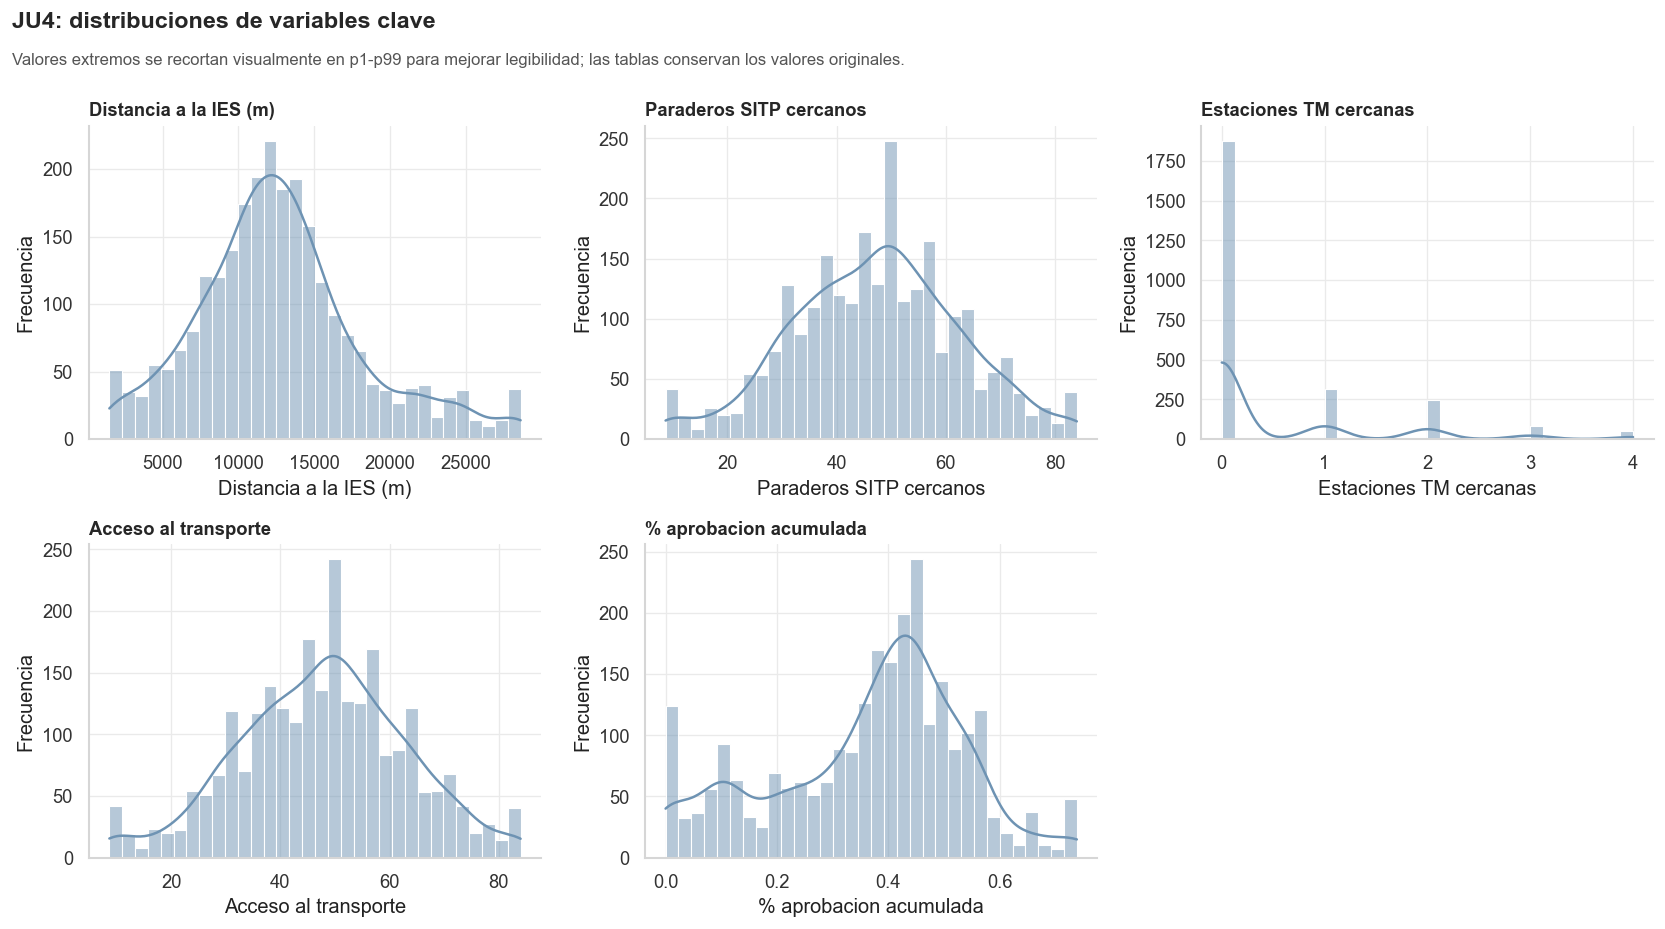

In [19]:
plot_distribuciones(ju4, "JU4", FIGURES_DIR);

## JU4 - Distancia a la IES vs desempeno

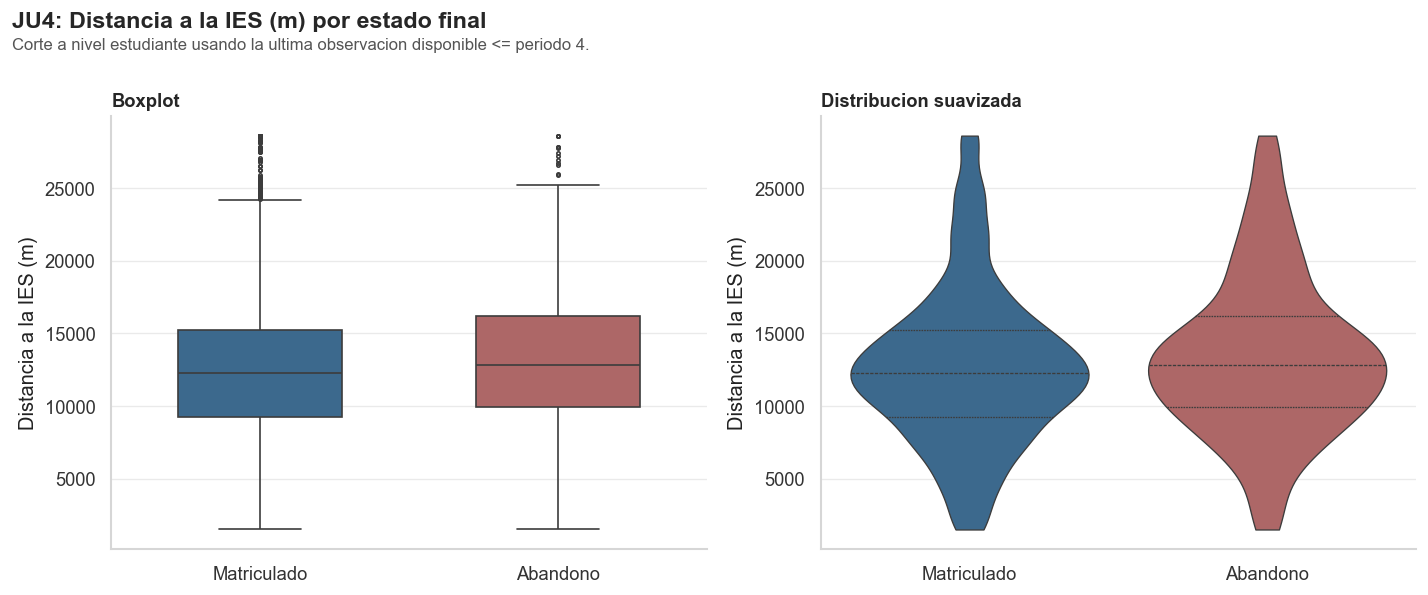

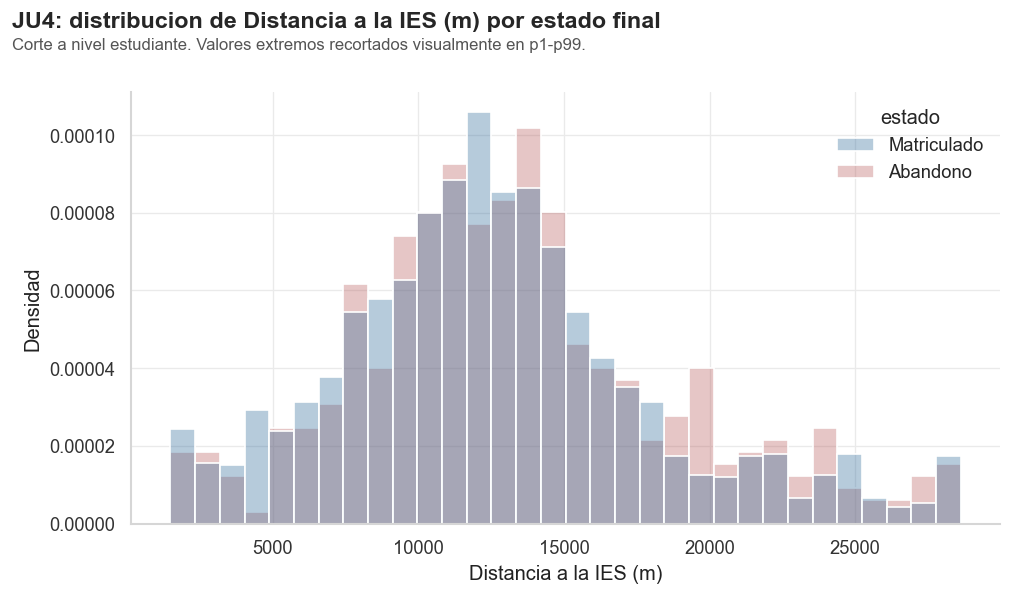

In [20]:
plot_comparacion_estado(ju4, "JU4", "distancia_ies", FIGURES_DIR);
plot_histograma_por_estado(ju4, "JU4", "distancia_ies", FIGURES_DIR);

## JU4 - Acceso al transporte vs desempeno

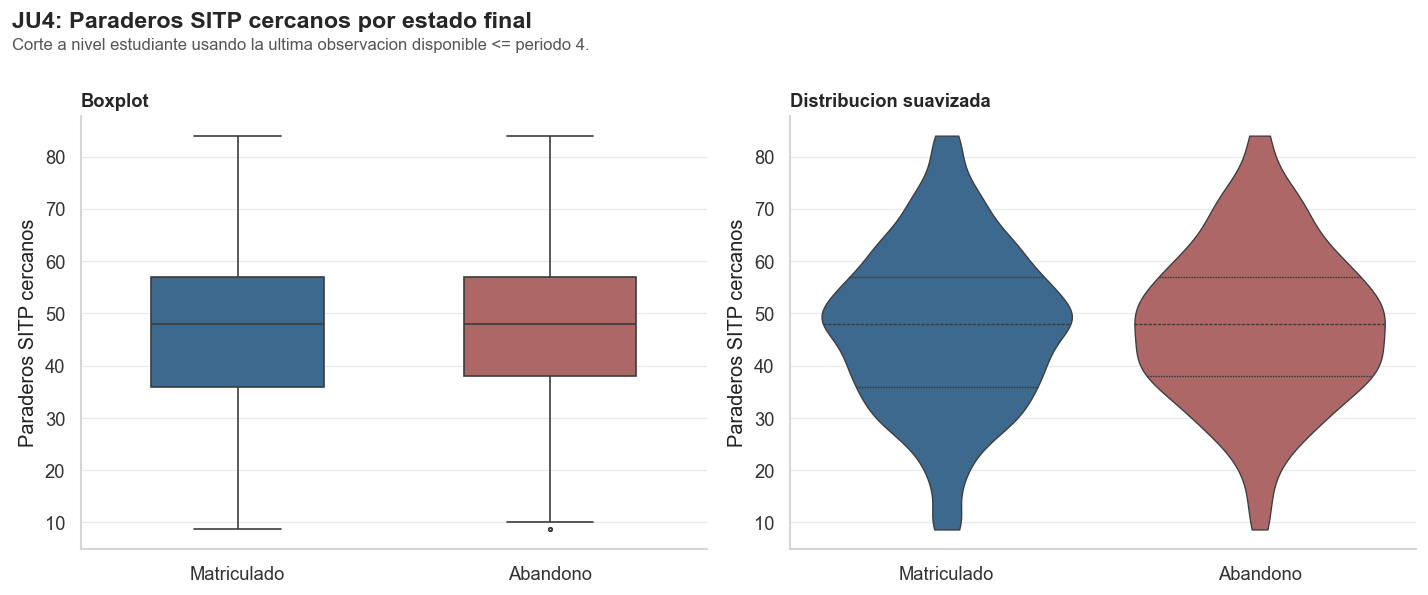

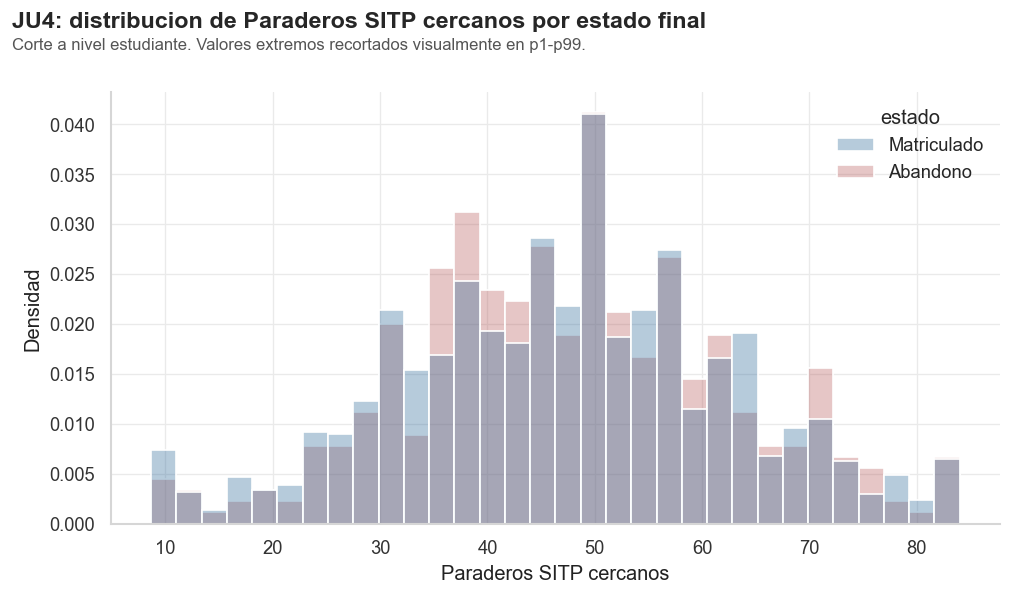

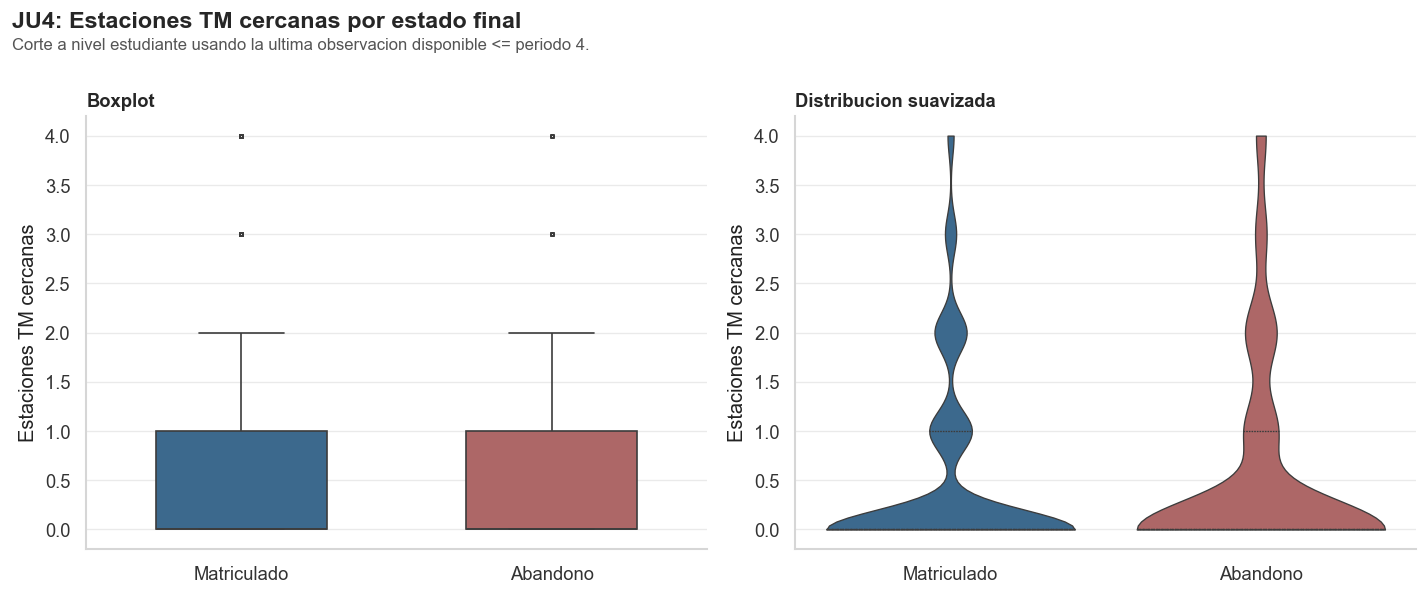

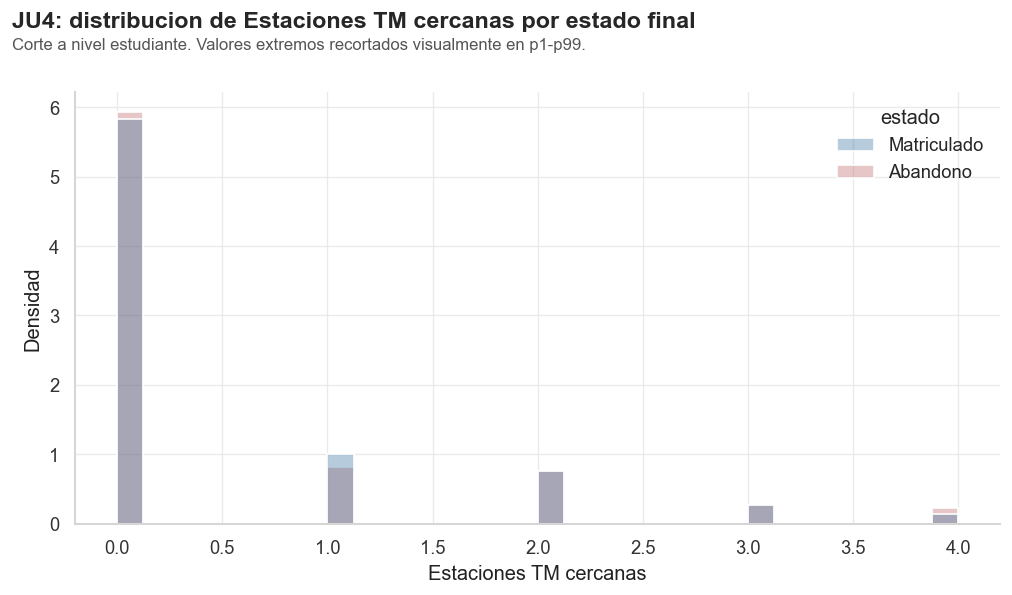

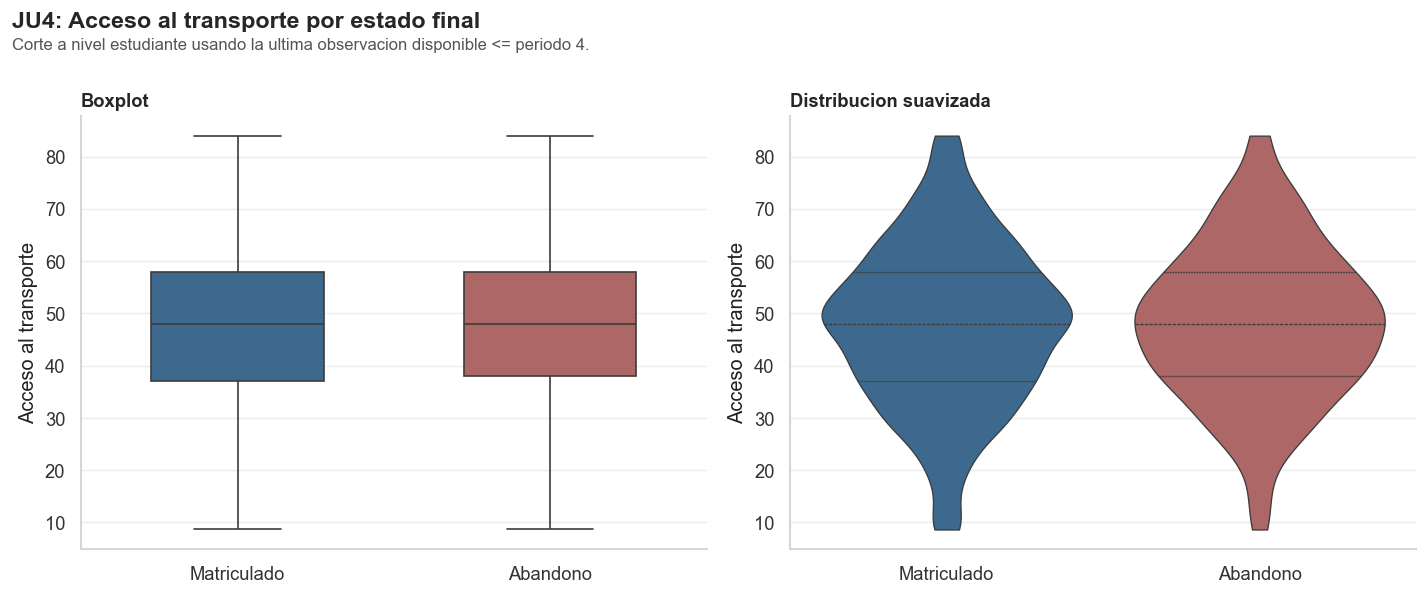

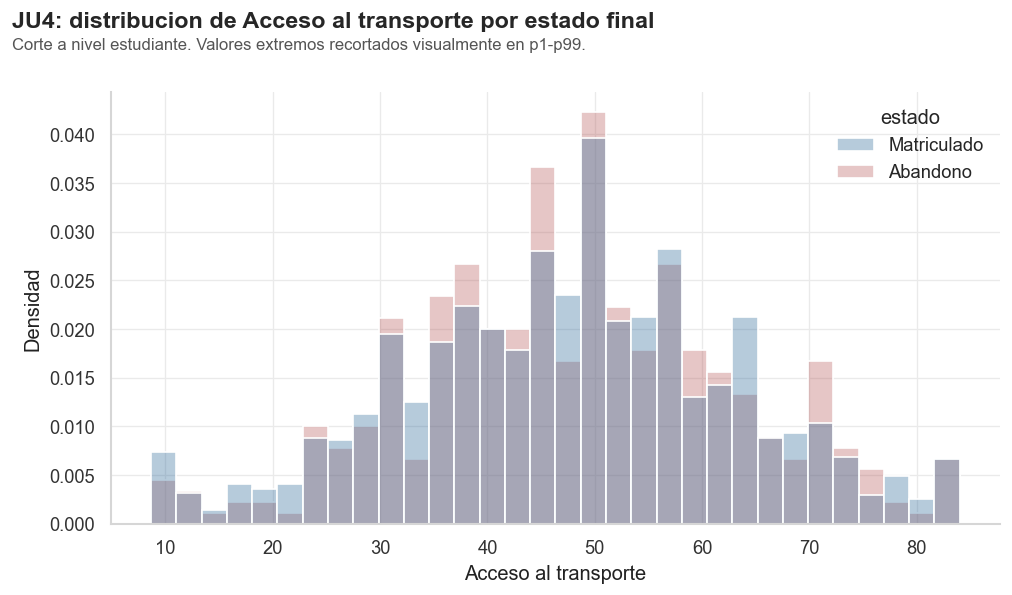

In [21]:
for variable in ["sitp_cercanos", "tm_cercanos", "acceso_transporte"]:
    plot_comparacion_estado(ju4, "JU4", variable, FIGURES_DIR)
    plot_histograma_por_estado(ju4, "JU4", variable, FIGURES_DIR)

## JU4 - Curvas promedio de desempeno

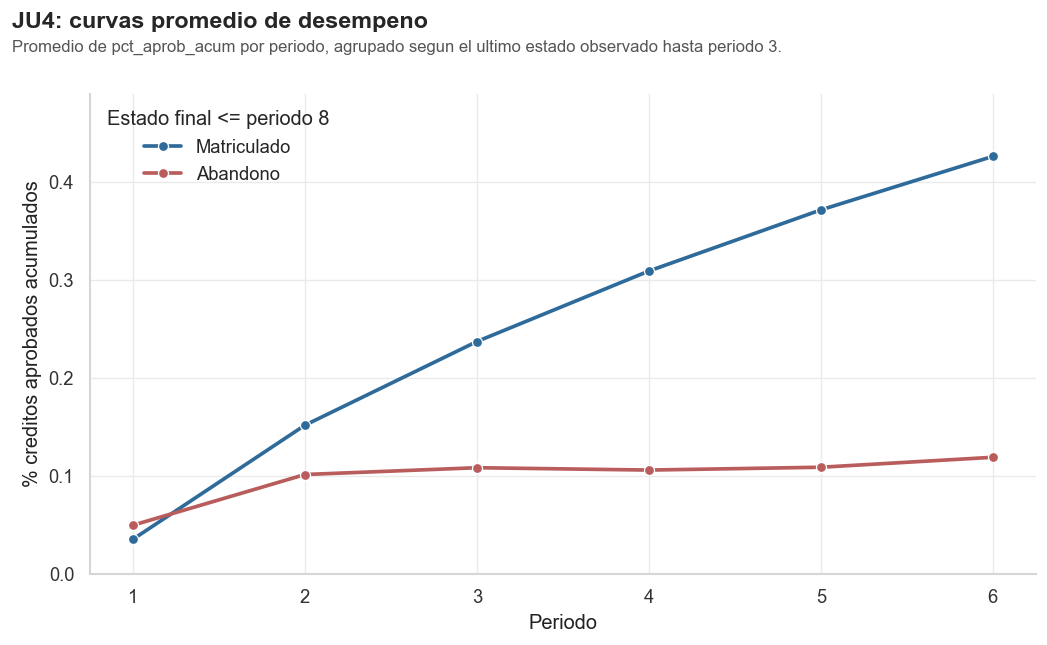

In [22]:
plot_curvas_promedio(ju4, "JU4", FIGURES_DIR);

## JU4 - Correlaciones

,distancia_ies,sitp_cercanos,tm_cercanos,acceso_transporte,pct_aprob_acum
distancia_ies,1.000,-0.036,-0.198,-0.048,-0.014
sitp_cercanos,-0.036,1.000,-0.042,0.998,-0.005
tm_cercanos,-0.198,-0.042,1.000,0.021,-0.000
acceso_transporte,-0.048,0.998,0.021,1.000,-0.005
pct_aprob_acum,-0.014,-0.005,-0.000,-0.005,1.000


- Distancia a la IES (m) y % aprobacion acumulada muestran una asociacion negativa de magnitud baja (r = -0.014).
- Paraderos SITP cercanos y % aprobacion acumulada muestran una asociacion negativa de magnitud baja (r = -0.005).
- Estaciones TM cercanas y % aprobacion acumulada muestran una asociacion nula de magnitud baja (r = -0.000).
- Acceso al transporte y % aprobacion acumulada muestran una asociacion negativa de magnitud baja (r = -0.005).

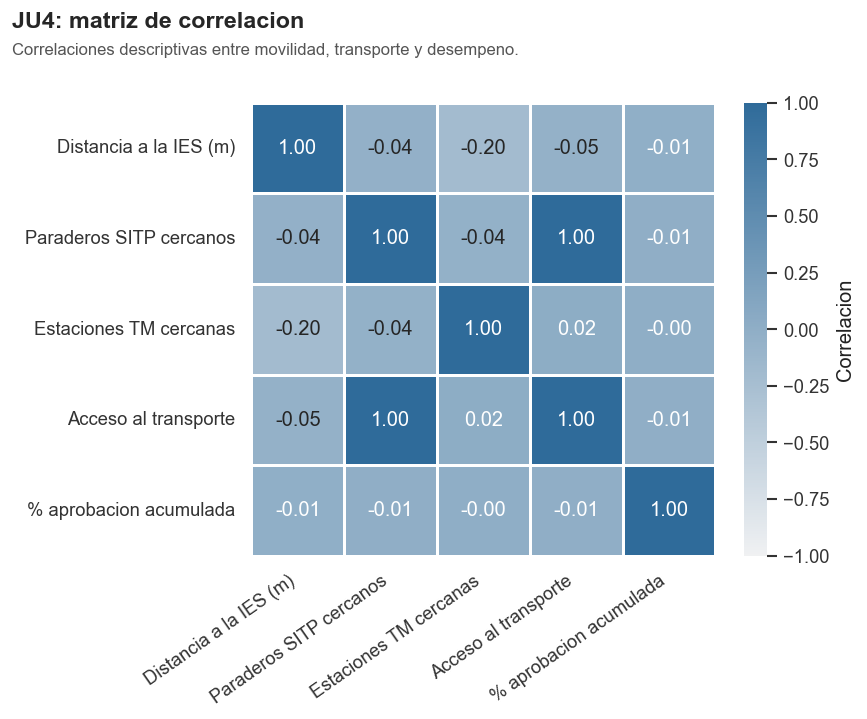

In [23]:
ju4_ultimo = ultima_observacion_por_estudiante(ju4)
corr_ju4 = matriz_correlacion(ju4_ultimo)
display(corr_ju4)
display(Markdown(interpretar_correlaciones(corr_ju4)))
plot_matriz_correlacion(ju4_ultimo, "JU4", FIGURES_DIR);

## JU4 - Relaciones bivariadas

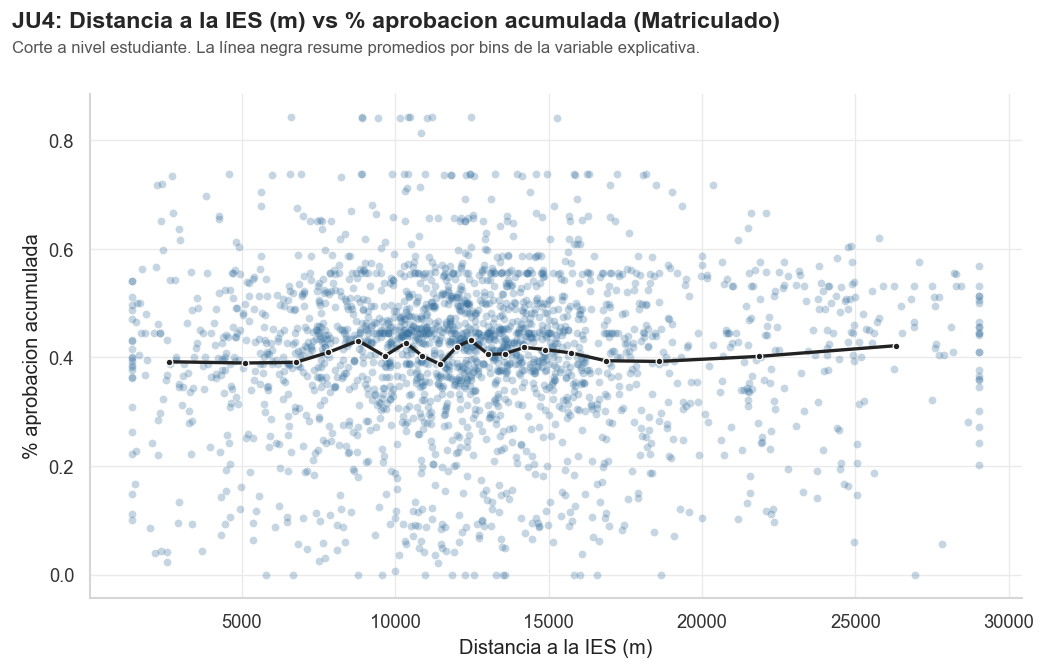

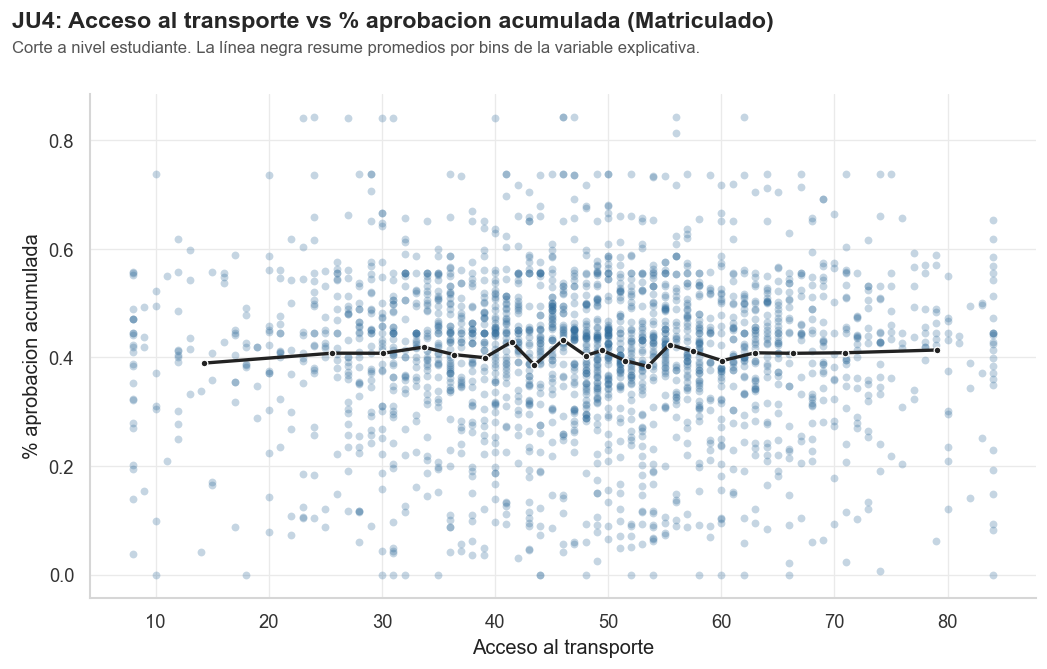

In [24]:
plot_relacion_bivariada(ju4, "JU4", "distancia_ies", "pct_aprob_acum", FIGURES_DIR);
plot_relacion_bivariada(ju4, "JU4", "acceso_transporte", "pct_aprob_acum", FIGURES_DIR);

## JU4 - Analisis por quintiles

,quintil,estudiantes,valor_min,valor_max,pct_aprob_promedio,tasa_abandono
0,Q1,514,431.0484,8436.7787,0.3601,0.1245
1,Q2,513,8463.1681,11219.0170,0.3711,0.1481
2,Q3,513,11219.8440,13413.7400,0.3723,0.1345
3,Q4,513,13420.7458,16332.3266,0.3682,0.1559
4,Q5,514,16335.8597,35215.7286,0.3503,0.1809


,quintil,estudiantes,valor_min,valor_max,pct_aprob_promedio,tasa_abandono
0,Q1,543,2,35,0.3693,0.1289
1,Q2,497,36,44,0.3579,0.1710
2,Q3,561,45,52,0.3666,0.1551
3,Q4,479,53,61,0.3619,0.1441
4,Q5,487,62,92,0.3655,0.1458


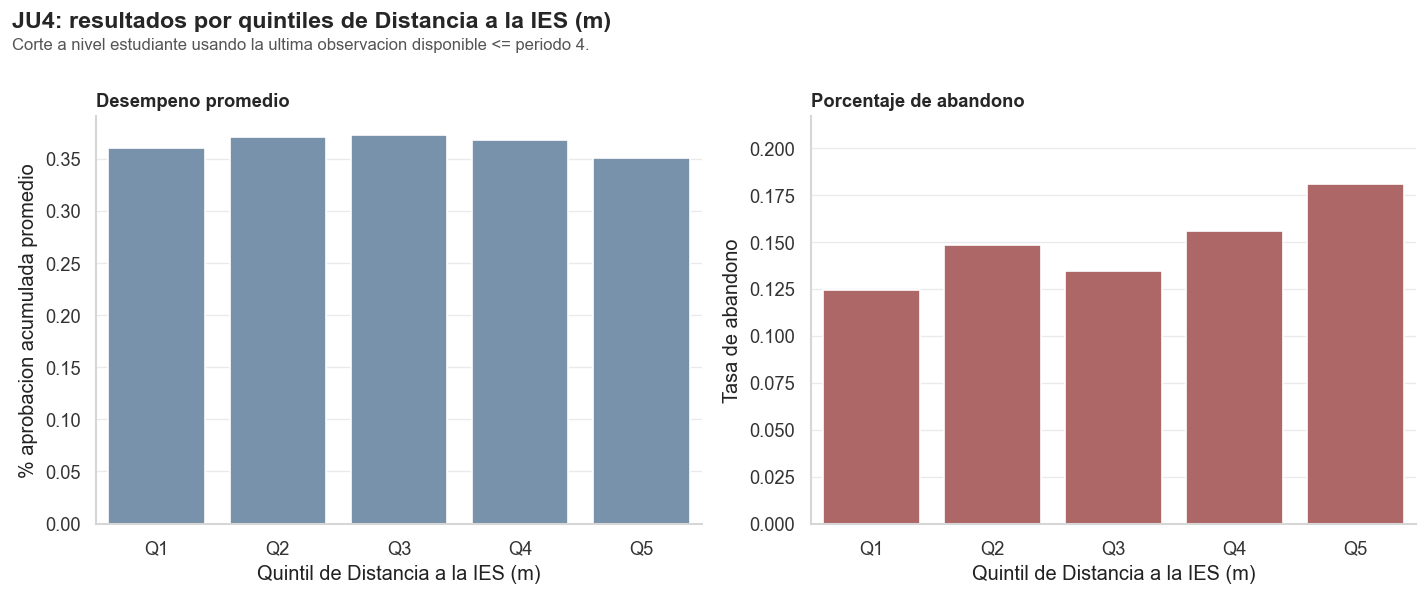

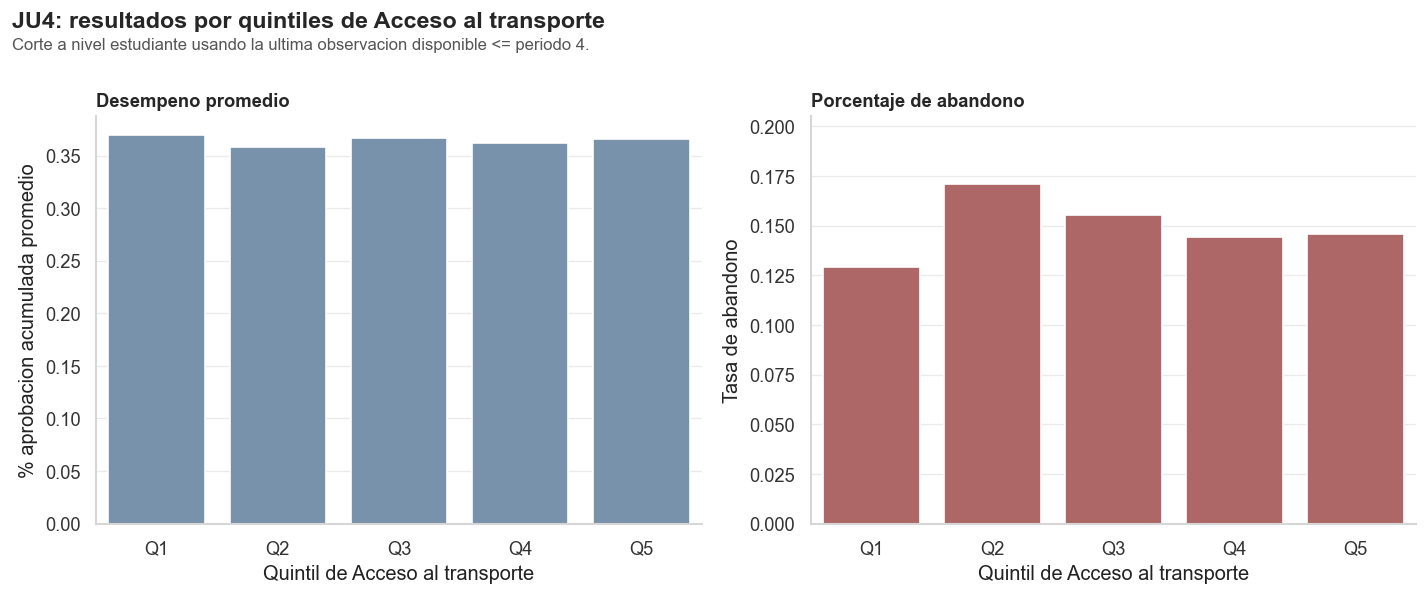

In [25]:
ju4_quintiles_distancia = resumen_quintiles(ju4, "distancia_ies")
ju4_quintiles_transporte = resumen_quintiles(ju4, "acceso_transporte")

display(ju4_quintiles_distancia)
plot_quintiles(ju4_quintiles_distancia, "JU4", "distancia_ies", FIGURES_DIR);

display(ju4_quintiles_transporte)
plot_quintiles(ju4_quintiles_transporte, "JU4", "acceso_transporte", FIGURES_DIR);

## JU4 - Tasas de abandono acumuladas

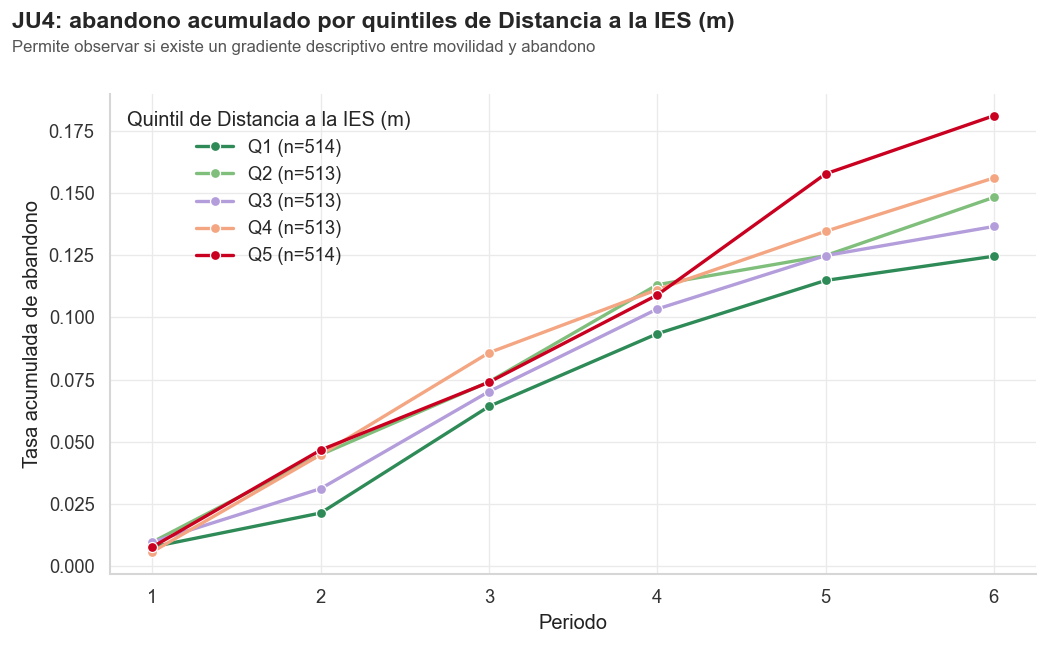

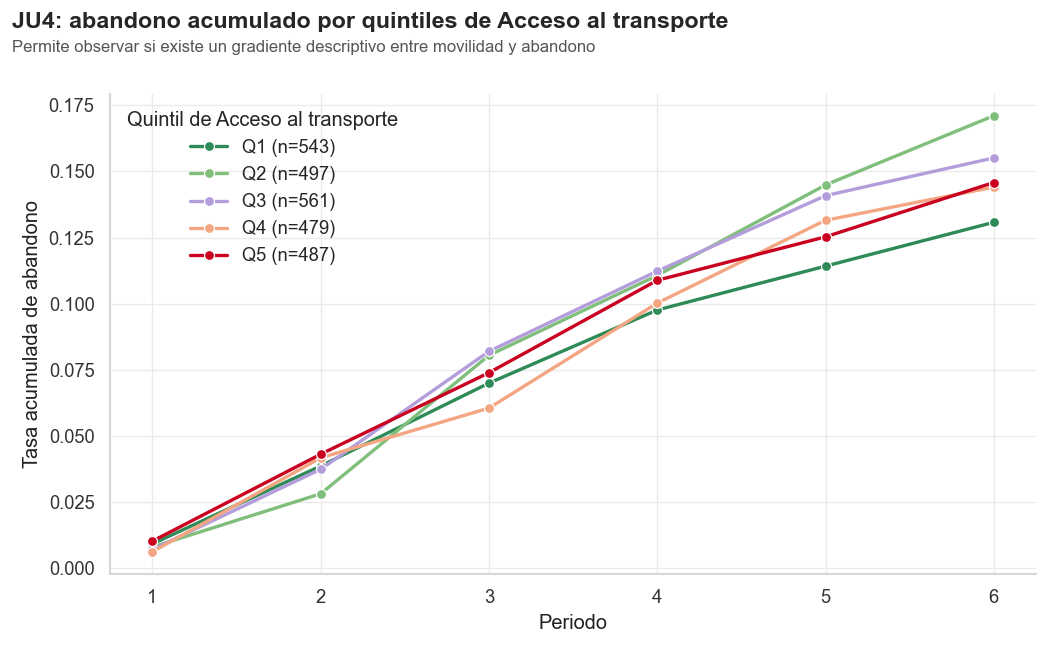

In [26]:
ju4_abandono_distancia = tasa_abandono_acumulada_por_quintil(ju4, "distancia_ies")
ju4_abandono_transporte = tasa_abandono_acumulada_por_quintil(ju4, "acceso_transporte")

plot_tasa_abandono_acumulada(ju4_abandono_distancia, "JU4", "distancia_ies", FIGURES_DIR);
plot_tasa_abandono_acumulada(ju4_abandono_transporte, "JU4", "acceso_transporte", FIGURES_DIR);

## JU4 - Conclusiones

In [27]:
conclusiones_ju4 = generar_conclusiones(ju4, "JU4")
guardar_texto(conclusiones_ju4, OUTPUTS_DIR / "ju4_conclusiones.md")
display(Markdown(conclusiones_ju4))

### Conclusiones descriptivas - JU4

- La muestra filtrada contiene **2,567 estudiantes** con ultima observacion disponible hasta el periodo 4.
- En el corte final, la distancia promedio a la IES es de **12,668 m** para Matriculado y **13,409 m** para Abandono.
- El acceso promedio al transporte es de **47.7 puntos cercanos** para Matriculado y **48.2** para Abandono.
- El desempeno promedio acumulado es de **0.407** para Matriculado y **0.119** para Abandono.
- La correlacion descriptiva entre distancia a la IES y desempeno es **-0.014**; entre acceso al transporte y desempeno es **-0.005**.
- Entre el quintil mas bajo y mas alto de distancia, la tasa de abandono cambia en **5.64%**. Entre el quintil mas bajo y mas alto de acceso al transporte, cambia en **1.69%**.
- Estos patrones son asociaciones descriptivas. No deben interpretarse como efectos causales, pero si ayudan a priorizar especificaciones y controles para el analisis econometrico posterior.